In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

## Load scores and plotting metadata

In [2]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/essential_lfc.csv", index_col=0)

In [3]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = fig_index["fine_tuning"]
model_type_palette = fig_index['genes_model_type_palette']
hue_order = fig_index['genes_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
# mpl.rcParams.update({"legend.loc": "upper right"})

In [4]:
df = df[df["cell_line"] == "K-562"]

# Fine-tuning figure

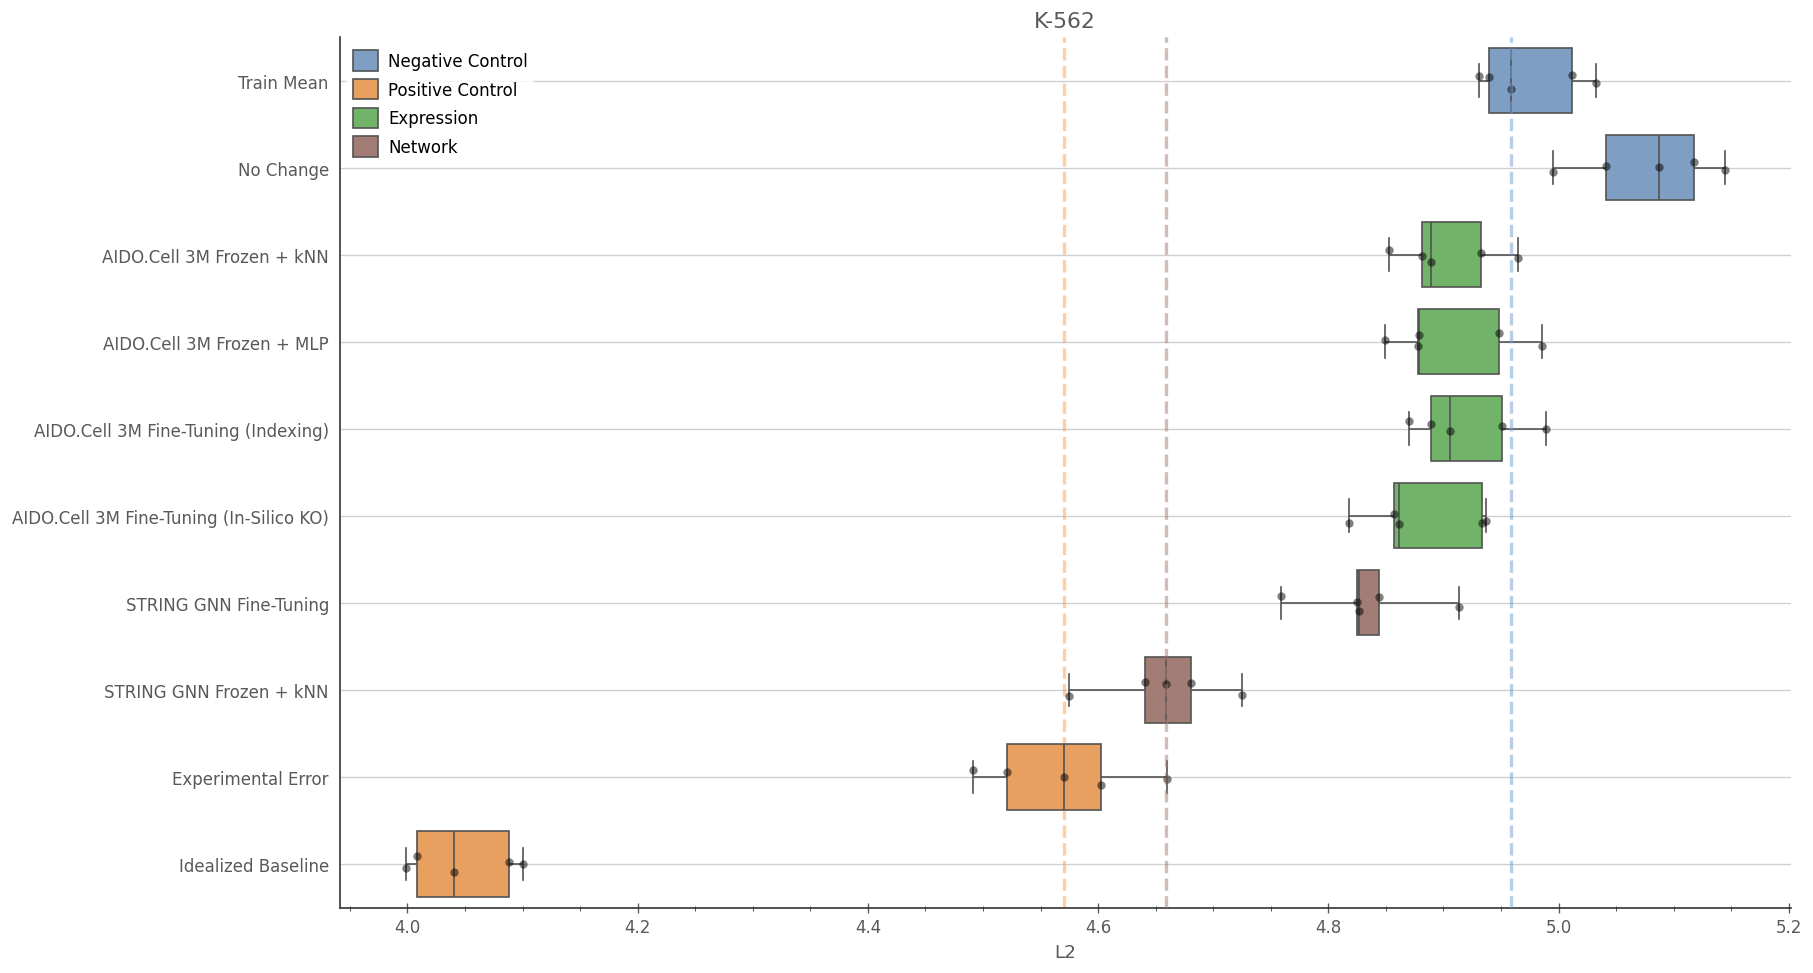

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8), constrained_layout=True)

# Filter data
method_list = list(method_map.keys())
idx = df["name"].isin(method_list)
df_subset = df[idx].copy()
df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

# Create boxplot
order = [name for name, _ in method_map.values()]

g = sns.boxplot(
    data=df_subset, 
    y="name", 
    order=order, 
    hue="Model type",
    x="L2", 
    ax=ax, 
    whis=(0, 100), 
    width=0.75, 
    palette=model_type_palette
)
g.legend(title=None)

sns.stripplot(
    data=df_subset, 
    y="name", 
    order=order, 
    x="L2", 
    ax=ax,
    color="black",
    alpha=0.5,
)

# Get the best performing model
best_mask = (
    (df_subset["Model type"] != "Positive Control") &
    (df_subset["Model type"] != "Fusion")
)
best_group = (
    df_subset.loc[best_mask]
    .groupby("name")["L2"]
    .median()
)
best_name = best_group.idxmin()
best_level = best_group.loc[best_name]
best_model_type = (
    df_subset.loc[df_subset["name"] == best_name, "Model type"]
    .iloc[0]
)

# Draw vertical lines
train_mean_level = df_subset[df_subset["name"] == "Train Mean"]["L2"].median()
exp_err_level = df_subset[df_subset["name"] == f"Experimental Error"]["L2"].median()
g.axvline(train_mean_level, color=model_type_palette["Negative Control"], linestyle="--", linewidth=2, zorder=99, alpha=.5, label="Train mean")
g.axvline(exp_err_level, color=model_type_palette["Positive Control"], linestyle="--", linewidth=2, zorder=-99, alpha=.5, label="Experimental error")
g.axvline(best_level, color=model_type_palette[best_model_type], linestyle="--", linewidth=2, zorder=99, alpha=.5, label="Best method")

# Decorate
g.grid(axis="y")
g.set_xlabel('L2')
g.set_title('K-562')
g.set_ylabel(None)
sns.despine()
plt.savefig("fig_4.pdf")